# ==================================================
# Task 1: Load Dataset
# ==================================================

##Load Dataset & Define Features/Labels

In [16]:
# Import Libraries
import pandas as pd
import numpy as np

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("/content/cleaned_data.csv")

In [17]:
# Display basic information
print("First 5 Rows:")
display(df.head())

print("\nShape:", df.shape)

print("\nData Types:")
display(df.dtypes)

First 5 Rows:


,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080



Shape: (1274, 11)

Data Types:


,0
Company,object
TypeName,object
Inches,float64
ScreenResolution,object
Cpu,object
Ram,int64
Memory,object
Gpu,object
OpSys,object
Weight,float64


In [18]:
# Define Labels
# For this dataset, the best regression target is: Price
# Regression target
y_reg = df["Price"]

# Classification target
y_clf = (df["Price"] > df["Price"].median()).astype(int)

In [19]:
# Remove the target column
# Feature Matrix
X = df.drop(columns=["Price"])

print("Feature Matrix Shape:", X.shape)
print("Regression Label Shape:", y_reg.shape)
print("Classification Label Shape:", y_clf.shape)

Feature Matrix Shape: (1274, 10)
Regression Label Shape: (1274,)
Classification Label Shape: (1274,)


# ==================================================
# Task 2: Encode Categorical Columns
# ==================================================

In [20]:
# Find categorical columns
categorical_cols = X.select_dtypes(include=["object", "category"]).columns

print("Categorical Columns:")
print(categorical_cols.tolist())

Categorical Columns:
['Company', 'TypeName', 'ScreenResolution', 'Cpu', 'Memory', 'Gpu', 'OpSys']


In [21]:
# Apply One-Hot Encoding
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

print("\nFeature Matrix Shape After Encoding:", X.shape)

display(X.head())


Feature Matrix Shape After Encoding: (1274, 338)


,Inches,Ram,Weight,Company_Apple,Company_Asus,Company_Chuwi,Company_Dell,Company_Fujitsu,Company_Google,Company_HP,...,Gpu_Nvidia Quadro M620,Gpu_Nvidia Quadro M620M,OpSys_Chrome OS,OpSys_Linux,OpSys_Mac OS X,OpSys_No OS,OpSys_Windows 10,OpSys_Windows 10 S,OpSys_Windows 7,OpSys_macOS
0,13.3,8,1.37,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,13.3,8,1.34,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,15.6,8,1.86,0,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
3,15.4,16,1.83,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,13.3,8,1.37,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


# ==================================================
# Task 3: Train-Test Split & Feature Scaling
# ==================================================

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Regression Split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y_reg,
    test_size=0.2,
    random_state=42
)

# Classification Split
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X,
    y_clf,
    test_size=0.2,
    random_state=42
)

# Standard Scaling
scaler = StandardScaler()

In [23]:
# Regression
X_train_reg_scaled = scaler.fit_transform(X_train_reg)
X_test_reg_scaled = scaler.transform(X_test_reg)

# Classification
X_train_clf_scaled = scaler.fit_transform(X_train_clf)
X_test_clf_scaled = scaler.transform(X_test_clf)

In [24]:
print("Regression Training Shape:", X_train_reg_scaled.shape)
print("Regression Testing Shape :", X_test_reg_scaled.shape)

print("\nClassification Training Shape:", X_train_clf_scaled.shape)
print("Classification Testing Shape :", X_test_clf_scaled.shape)

Regression Training Shape: (1019, 338)
Regression Testing Shape : (255, 338)

Classification Training Shape: (1019, 338)
Classification Testing Shape : (255, 338)


# ==================================================
# Task 4: Linear Regression
# ==================================================


In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Create model
linear_model = LinearRegression()

# Train model
linear_model.fit(
    X_train_reg_scaled,
    y_train_reg
)

LinearRegression()

In [26]:
# Predict on test data
y_pred_reg = linear_model.predict(
    X_test_reg_scaled
)

In [27]:
# Evaluation Metrics
mse = mean_squared_error(
    y_test_reg,
    y_pred_reg
)

r2 = r2_score(
    y_test_reg,
    y_pred_reg
)

print("Mean Squared Error:", round(mse, 2))
print("R² Score:", round(r2, 4))

Mean Squared Error: 268041200.38
R² Score: 0.8282


In [28]:
# Coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

display(coefficients)

,Feature,Coefficient
0,Inches,-998.473186
1,Ram,2268.222211
2,Weight,-371.724254
3,Company_Apple,173.149675
4,Company_Asus,1147.065761
...,...,...
333,OpSys_No OS,-2054.581665
334,OpSys_Windows 10,568.797427
335,OpSys_Windows 10 S,-130.485932
336,OpSys_Windows 7,3126.712485


In [29]:
# Top 3 Largest Coefficients
top3 = coefficients.reindex(
    coefficients["Coefficient"].abs().sort_values(ascending=False).index
).head(3)

print("Top 3 Features by Absolute Coefficient")

display(top3)

Top 3 Features by Absolute Coefficient


,Feature,Coefficient
300,Gpu_Nvidia GeForce GTX 1070,7796.386542
166,Cpu_Intel Core i7 7700HQ 2.8GHz,5502.426405
210,Memory_512GB SSD,5422.199414


## ==================================================
## Task: Ridge Regression
## ==================================================

In [30]:
from sklearn.linear_model import Ridge

# Create Ridge model
ridge_model = Ridge(alpha=1.0)

In [31]:
# Train
ridge_model.fit(
    X_train_reg_scaled,
    y_train_reg
)

# Predict
y_pred_ridge = ridge_model.predict(
    X_test_reg_scaled
)

In [32]:
# Evaluation
ridge_mse = mean_squared_error(
    y_test_reg,
    y_pred_ridge
)

ridge_r2 = r2_score(
    y_test_reg,
    y_pred_ridge
)

print("Ridge Mean Squared Error:", round(ridge_mse, 2))
print("Ridge R² Score:", round(ridge_r2, 4))

Ridge Mean Squared Error: 267435255.18
Ridge R² Score: 0.8285


In [33]:
# Comparision Table
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "MSE": [mse, ridge_mse],
    "R² Score": [r2, ridge_r2]
})

print("Regression Model Comparison:")
display(comparison.round(4))

Regression Model Comparison:


,Model,MSE,R² Score
0,Linear Regression,2.680412e+08,0.8282
1,Ridge Regression,2.674353e+08,0.8285


# ==================================================
# Task 5: Logistic Regression
# ==================================================

In [34]:
y_clf.value_counts() # class distribution

,count
Price,
0,644
1,630


In [35]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000)

# Train the model
logistic_model.fit(
    X_train_clf_scaled,
    y_train_clf
)

LogisticRegression(max_iter=1000)

In [36]:
# Predict class labels
y_pred_clf = logistic_model.predict(X_test_clf_scaled)

# Predict probabilities
y_prob_clf = logistic_model.predict_proba(X_test_clf_scaled)[:, 1]

In [37]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test_clf,
    y_pred_clf
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[126  14]
 [ 10 105]]


In [38]:
# Classification Report
from sklearn.metrics import classification_report

print("Classification Report:\n")

print(classification_report(
    y_test_clf,
    y_pred_clf
))

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.90      0.91       140
           1       0.88      0.91      0.90       115

    accuracy                           0.91       255
   macro avg       0.90      0.91      0.91       255
weighted avg       0.91      0.91      0.91       255



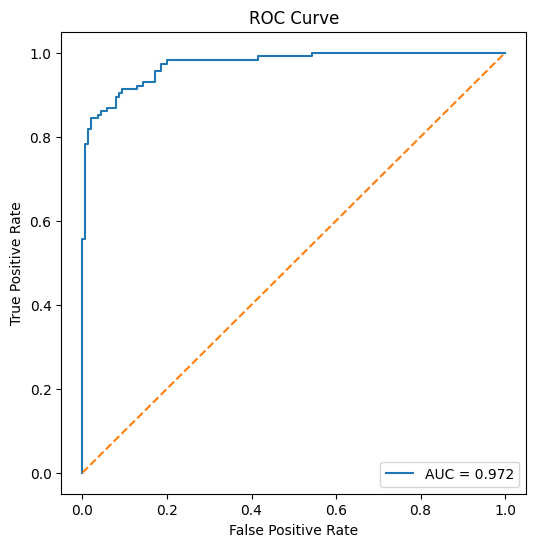

AUC Score: 0.9724


In [39]:
# ROC Curve and AUC
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(
    y_test_clf,
    y_prob_clf
)

auc = roc_auc_score(
    y_test_clf,
    y_prob_clf
)

# Plot ROC Curve
plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")

plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

print("AUC Score:", round(auc,4))

## ==================================================
## Task 5b: Decision Threshold Sensitivity
## ==================================================

In [40]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

results = []

for threshold in thresholds:

    predictions = (y_prob_clf >= threshold).astype(int)

    precision = precision_score(y_test_clf, predictions)
    recall = recall_score(y_test_clf, predictions)
    f1 = f1_score(y_test_clf, predictions)

    results.append({
        "Threshold": threshold,
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1 Score": round(f1, 4)
    })

threshold_results = pd.DataFrame(results)

print("Threshold Comparison:")
display(threshold_results)

Threshold Comparison:


,Threshold,Precision,Recall,F1 Score
0,0.3,0.8195,0.9478,0.8790
1,0.4,0.8425,0.9304,0.8843
2,0.5,0.8824,0.9130,0.8974
3,0.6,0.9035,0.8957,0.8996
4,0.7,0.9259,0.8696,0.8969


In [42]:
# Find the Best Threshold
best_threshold = threshold_results.loc[
    threshold_results["F1 Score"].idxmax()
]

print("Best Threshold Based on F1 Score:")
display(best_threshold)

Best Threshold Based on F1 Score:


,3
Threshold,0.6000
Precision,0.9035
Recall,0.8957
F1 Score,0.8996


# ==================================================
# Task 6: Logistic Regression Regularization
# ==================================================

In [43]:
# Logistic Regression with stronger regularization
logistic_model_reg = LogisticRegression(
    C=0.01,
    max_iter=1000
)

# Train
logistic_model_reg.fit(
    X_train_clf_scaled,
    y_train_clf
)

# Predictions
y_pred_reg = logistic_model_reg.predict(X_test_clf_scaled)

# Probabilities
y_prob_reg = logistic_model_reg.predict_proba(X_test_clf_scaled)[:, 1]

In [44]:
# Compute Metrics
from sklearn.metrics import precision_score, recall_score, roc_auc_score

precision_reg = precision_score(y_test_clf, y_pred_reg)

recall_reg = recall_score(y_test_clf, y_pred_reg)

auc_reg = roc_auc_score(y_test_clf, y_prob_reg)

print("Precision:", round(precision_reg,4))
print("Recall:", round(recall_reg,4))
print("AUC:", round(auc_reg,4))

Precision: 0.8862
Recall: 0.9478
AUC: 0.9784


In [45]:
# Comparison Table
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression (C=1.0)",
        "Logistic Regression (C=0.01)"
    ],
    "Precision": [
        precision_score(y_test_clf, y_pred_clf),
        precision_reg
    ],
    "Recall": [
        recall_score(y_test_clf, y_pred_clf),
        recall_reg
    ],
    "AUC": [
        roc_auc_score(y_test_clf, y_prob_clf),
        auc_reg
    ]
})

print("Logistic Regression Comparison:")
display(comparison.round(4))

Logistic Regression Comparison:


,Model,Precision,Recall,AUC
0,Logistic Regression (C=1.0),0.8824,0.9130,0.9724
1,Logistic Regression (C=0.01),0.8862,0.9478,0.9784


# ==================================================
# Task 7: Bootstrap Confidence Interval
# ==================================================

In [46]:
auc_differences = []

for _ in range(500):

    indices = np.random.choice(
        len(y_test_clf),
        size=len(y_test_clf),
        replace=True
    )

    y_true = y_test_clf.iloc[indices]

    prob1 = y_prob_clf[indices]
    prob2 = y_prob_reg[indices]

    auc1 = roc_auc_score(y_true, prob1)
    auc2 = roc_auc_score(y_true, prob2)

    auc_differences.append(auc1 - auc2)

In [47]:
# Mean Difference
mean_difference = np.mean(auc_differences)

# 95% Confidence Interval
lower = np.percentile(auc_differences, 2.5)
upper = np.percentile(auc_differences, 97.5)

print("Mean AUC Difference:", round(mean_difference,4))
print("95% Confidence Interval:")
print("Lower:", round(lower,4))
print("Upper:", round(upper,4))

Mean AUC Difference: -0.0059
95% Confidence Interval:
Lower: -0.0158
Upper: 0.003


In [48]:
if lower > 0 or upper < 0:
    print("\nThe confidence interval excludes zero.")
else:
    print("\nThe confidence interval includes zero.")


The confidence interval includes zero.
